# Notebook workflow - Nano Texturing 

This notebook uses the modified `PyramidTool` workflow to extract pyramid-size information from top-view SEM images. The complete analysis consists of five main stages:

1. **Calibrate the SEM image** using the scale bar to obtain the pixel size.
2. **Segment the pyramids** using the watershed-based `PyramidTool`.
3. **Manually correct apex markers** where the automatic segmentation is incomplete.
4. **Measure four rays per pyramid** and save the corrected `.npz` measurement files.
5. **Post-process the measurements** into maximum vertex size, estimated pyramid height, histograms, boxplots, and summary statistics.

The final model used here is the **Unbordered-Maximum** approach: border-touching pyramids are excluded, and the largest measured ray is used to represent each pyramid.

### Step 1 — Load the raw SEM image

This first code cell opens one SEM micrograph without applying the final pixel-size calibration. The purpose is only to inspect the image and use the scale bar in the SEM image to determine the correct pixel size.

Set `image_name` to the file you want to analyse. The image must be located in the `./images/` folder. The option `autocrop=False` keeps the full SEM image visible, including the bottom information strip and the scale bar.

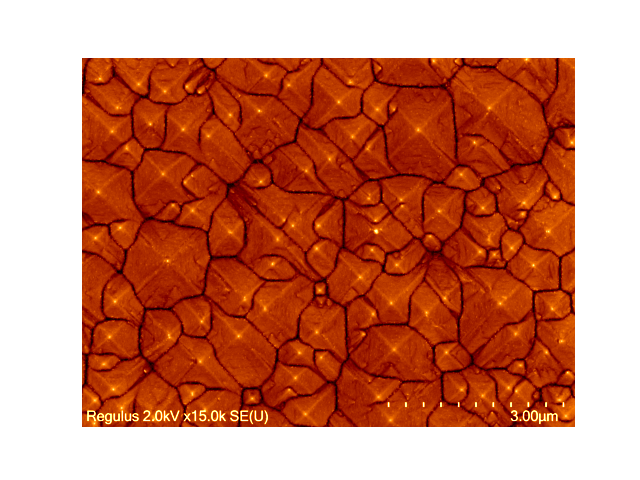

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
from pyramids.source1_altered_standard import Image

image_name = 'nano Text 50mL 70deg REAR.tif'
                                                                     # Change SEM image Name  
im = Image('./images/' + image_name, autocrop=False)
f, axs = im.show(scalebar_size=None)
plt.show()


### Step 2 — Calculate the pixel size from the SEM scale bar

The analysis needs a conversion factor from pixels to micrometres. This is obtained from the scale bar using

\[
p_s = \frac{S}{x_1-x_0}
\]

where \(S\) is the physical scale-bar length in micrometres, \(x_0\) is the left pixel position of the scale bar, and \(x_1\) is the right pixel position. After zooming in on the scale bar, manually enter the pixel positions in the code below. The calculated value `ps` is then used as the pixel size in \(\mu\text{m/pixel}\).

In [2]:
# Nano SEM images
S  = 3.     # scalebar size in µm (Change value if not aligned to SEM image scalebar)
x1 = 2500    # right pixel of the scale bar
x0 = 1593    # left ...
ps = S / (x1 - x0)

print('Pixel Size = {0:.5f} µm / pixel'.format(ps))

Pixel Size = 0.00331 µm / pixel


### Step 3 — Re-load the image with the calibrated pixel size

After calculating the pixel size, the same SEM image is loaded again using `pixel_size=ps`. This ensures that all measured lengths are reported in micrometres instead of pixels.

Here `autocrop=True` removes the bottom SEM information strip. This is important because the segmentation should only be applied to the actual SEM image area, not to the scale-bar/text region.

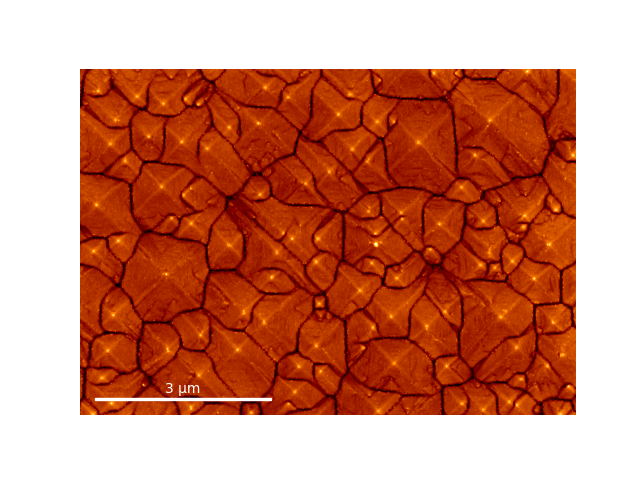

In [3]:
im = Image('./images/'+image_name, pixel_size=ps, scalebar_size=S, autocrop=True)
f, axs = im.show()
plt.show()

# Brief explanation of the modified source code

The notebook relies on the modified `source1_altered.py` implementation. The most important components are:

- `Image`: loads the SEM image, stores the pixel size, applies filters, and displays the image with a scale bar.
- `FindMaxima`: creates the foreground mask, detects one apex candidate per segmented region, and generates the initial watershed segmentation.
- `PyramidTool`: opens the interactive correction interface, allows apex markers to be added or removed, updates the watershed segmentation, measures the four ray vectors, and saves/loads the `.npz` measurement files.

In this version, the marker display and ray plotting were adjusted for clearer visual inspection: apex markers are shown larger and in red, while the measurement rays are plotted in dark blue.


### Step 4 — Create the output folder structure

The analysis saves different types of output files in separate folders. This keeps the workflow organised:

- `segmentation_max`: stores the watershed segmentation results and ray measurements.
- `vertex_data_max`: stores the maximum vertex size extracted from each pyramid.
- `pyramid_data_max`: stores the converted maximum pyramid heights.

The folders are created automatically if they do not already exist.

In [4]:
import os

BASE_DIR = "./results/Unbordered_Maximum"
DIR_SEG  = os.path.join(BASE_DIR, "segmentation_max")
DIR_VTX  = os.path.join(BASE_DIR, "vertex_data_max")
DIR_PYR  = os.path.join(BASE_DIR, "pyramid_data_max")

os.makedirs(DIR_SEG, exist_ok=True)
os.makedirs(DIR_VTX, exist_ok=True)
os.makedirs(DIR_PYR, exist_ok=True)


### Step 5 — Load image(s), preprocess, and start the interactive segmentation tool

This cell performs the main SEM segmentation step. Each image is loaded, filtered, and passed to the modified `PyramidTool`.

The key operations are:

1. **Load the SEM image** using the calibrated pixel size.
2. **Apply median filtering** with `size=15` to reduce image noise before segmentation.
3. **Detect pyramid apex candidates** automatically using the watershed-based workflow in `PyramidTool`.
4. **Open the interactive correction window**, where apex markers can be inspected and manually corrected.
5. **Re-load previous measurements** if a saved `.npz` file already exists.

During manual correction, left-clicking adds an apex marker and right-clicking removes the closest marker. In this version, `live_measure=False`, so clicking only updates the watershed segmentation. The ray measurements are calculated later in a separate step. This makes the interactive editing more stable and faster.

🔄 Loaded existing measurements for NT3-C REAR E.tif
🎯 Click to add/remove apexes. Only the watershed updates during editing.
🎯 Then run Cell 3 to compute the rays once.


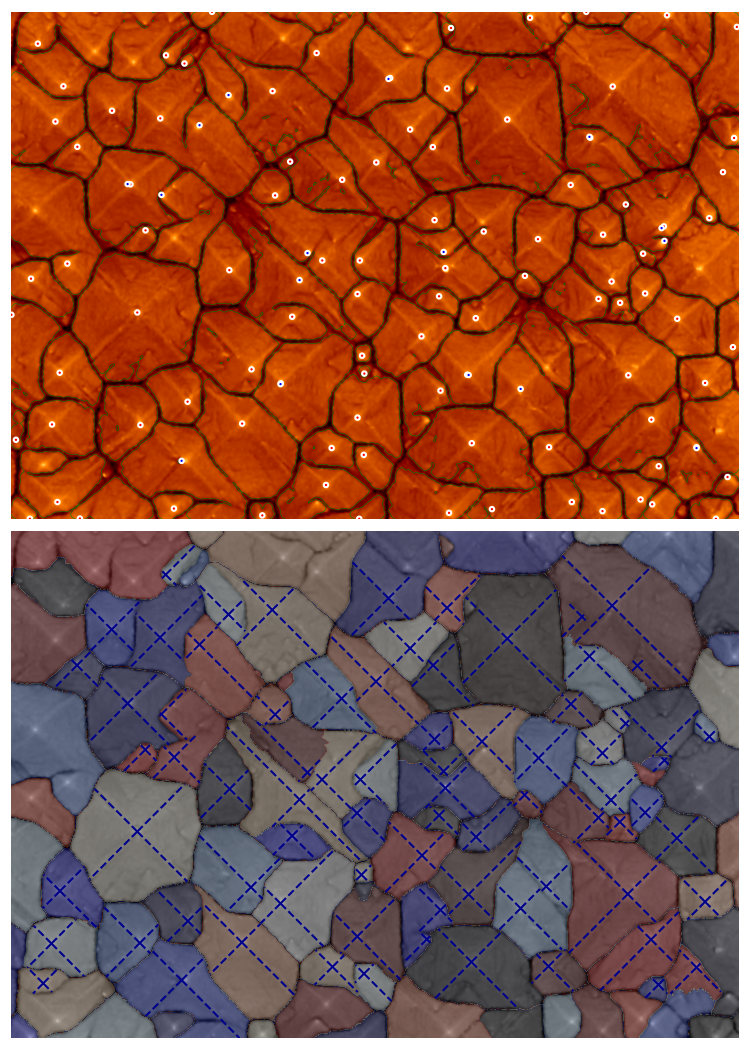

In [5]:
%matplotlib widget

import os
import numpy as np
import matplotlib.pyplot as plt
from pyramids.source1_altered_standard import Image, PyramidTool, addPoint

BASE_DIR = "./results/Unbordered_Maximum"
DIR_SEG = os.path.join(BASE_DIR, "segmentation_max")
os.makedirs(DIR_SEG, exist_ok=True)

image_names = [
    'nano Text 50mL 70deg REAR.tif',
]

pts = {}

for image_name in image_names:
    im = Image(
        f"./images/{image_name}",
        pixel_size=ps,
        scalebar_size=S,
        autocrop=True
    )

    im.median_filter(size=10)

    pt = PyramidTool(
        im,
        dpi=75,
        figsize=(10, 14),
        live_measure=False,
        freeze_deleted_regions=False
    )

    pts[image_name] = pt

    print(f"📝 Ready for manual clicks on {image_name}")

plt.show()

print("🎯 Click to add/remove apexes.")
print("🎯 After correction, run the next cell to compute the rays.")

### Step 6 — Re-measure all pyramids after manual correction

Once the apex positions and watershed regions look correct, this cell calculates the pyramid rays. For each segmented pyramid region, the algorithm traces four rays from the apex to the region boundary.

The parameter `pyramid_angle=45` defines the orientation of these four ray directions. The measured ray vectors are later used to calculate the maximum vertex size and the estimated pyramid height.

Before saving, inspect the plotted rays carefully. Incorrect apexes or wrongly segmented regions should be corrected in the previous interactive cell and then this cell should be run again.

In [6]:
for image_name, pt in pts.items():
    pt.measure_pyramids(pyramid_angle=45)
    pt.axes[1].figure.canvas.draw_idle()

print("✅ All images re-measured. Scroll back to the watershed figure and verify the rays.")

✅ All images re-measured. Verify the rays look correct, then run Cell 4 to save.


### Step 7 — Save the corrected measurements

This cell saves the final measurement file for each image. The saved `.npz` file contains:

- the pyramid centre/apex coordinates,
- the four ray vectors for each pyramid,
- the manually added markers.

Saving the manual markers is useful because the same corrected segmentation can be loaded again later without repeating the full manual correction.

In [7]:
import os

BASE_DIR = "./results/Unbordered_Maximum"
DIR_SEG  = os.path.join(BASE_DIR, "segmentation_max")
os.makedirs(DIR_SEG, exist_ok=True)

for image_name, pt in pts.items():
    meas_file = os.path.join(
        DIR_SEG,
        image_name.replace(".tif", "") + "- U-only method pyramid measurements.npz"
    )
    pt.save_pyramid_measurements(meas_file)
    print(f"💾 Saved merged measurements to {meas_file}")

print("🎉 Done! Your .npz files now include auto + manual apexes + saved manual markers.")

💾 Saved merged measurements to ./results/Unbordered_Maximum\segmentation_max\NT3-C REAR E- U-only method pyramid measurements.npz
🎉 Done! Your .npz files now include auto + manual apexes + saved manual markers.


### Step 8 — Calculate and plot the maximum vertex size

The saved segmentation file contains four ray vectors per pyramid. This cell converts each ray from pixels to micrometres and calculates its length using

\[
L = \sqrt{dx^2 + dy^2}\,p_s
\]

For each pyramid, the largest of the four ray lengths is selected as the **maximum vertex size**. This value represents the largest top-view distance from the apex to the segmented pyramid boundary.

The cell also saves a new `_vertexmax.npz` file. This smaller file is used by the later statistics and comparison cells, so the full segmentation does not need to be reloaded every time.

Saved vertex max NPZ: ./results/Unbordered_Maximum\vertex_data_max\NT3-C REAR E_vertexmax.npz (N=79)
Blue bars sum = 79 (expected 79)

Max vertex size (blue) — non-empty bins:
Bin             range [µm]   mid [µm]    count  % of pyramids
  1 [0.000, 0.080)      0.040        1            1.3%
  2 [0.080, 0.160)      0.120        2            2.5%
  3 [0.160, 0.240)      0.200        6            7.6%
  4 [0.240, 0.320)      0.280        7            8.9%
  5 [0.320, 0.400)      0.360        9           11.4%
  6 [0.400, 0.480)      0.440       11           13.9%
  7 [0.480, 0.560)      0.520        9           11.4%
  8 [0.560, 0.640)      0.600        8           10.1%
  9 [0.640, 0.720)      0.680        6            7.6%
 10 [0.720, 0.800)      0.760        5            6.3%
 11 [0.800, 0.880)      0.840        7            8.9%
 12 [0.880, 0.960)      0.920        4            5.1%
 13 [0.960, 1.040)      1.000        1            1.3%
 14 [1.120, 1.200)      1.160        2         

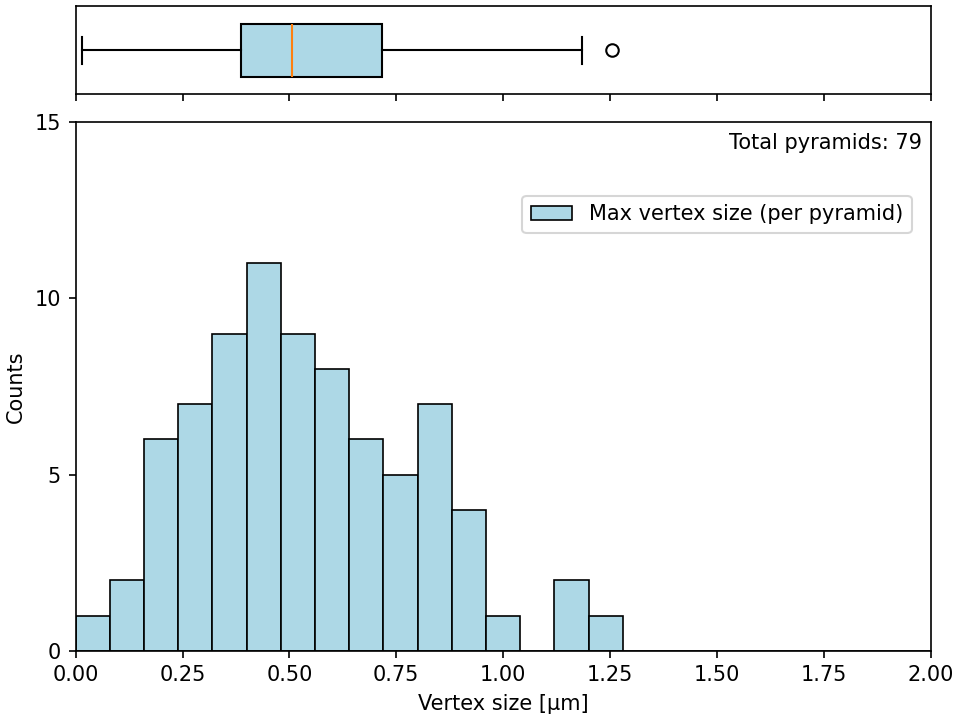

In [8]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
import math
import os

# ─────────────────────────────────────────────────────────
# Settings
# ─────────────────────────────────────────────────────────
image_name = 'nano Text 50mL 70deg REAR.tif'                                           # Change SEM Image Name 
ps = 0.00331                                                               # Change Pixel Size 

R = (0.0, 2.0)                                                             # x-range for vertex size histogram (µm)  <-- keep your 0..1
bins = 25                                                                  # number of bins

# ─────────────────────────────────────────────────────────
# Load measurements
# ─────────────────────────────────────────────────────────
BASE_DIR = "./results/Unbordered_Maximum"
DIR_SEG  = os.path.join(BASE_DIR, "segmentation_max")
DIR_VTX  = os.path.join(BASE_DIR, "vertex_data_max")
os.makedirs(DIR_VTX, exist_ok=True)

sname = os.path.join(
    DIR_SEG,
    image_name.replace(".tif", "- U-only method pyramid measurements.npz")
)
vertices = np.load(sname)["vertices"]  # (M,4,2)

M, _ = vertices.shape[0], vertices.shape[1]

# ─────────────────────────────────────────────────────────
# Max vertex size per pyramid (µm)
# ─────────────────────────────────────────────────────────
moduli = np.sqrt(np.sum(vertices**2, axis=-1)) * ps          # (M,4) µm
moduli_max = moduli.max(axis=1)                              # (M,)  µm
moduli_max = moduli_max[np.isfinite(moduli_max)]

# ─────────────────────────────────────────────────────────
# SAVE max vertex size data to NPZ  (NEW)
# ─────────────────────────────────────────────────────────
out_npz = os.path.join(DIR_VTX, image_name.replace(".tif", "_vertexmax.npz"))
np.savez(
    out_npz,
    image=image_name,
    moduli_max=moduli_max,
    ps=ps,
    M=len(moduli_max),
    R=np.array(R),
    bins=bins
)
print(f"Saved vertex max NPZ: {out_npz} (N={len(moduli_max)})")

# ─────────────────────────────────────────────────────────
# Bin summary (printed + optional table)
# ─────────────────────────────────────────────────────────
counts, edges = np.histogram(moduli_max, bins=bins, range=R)
print(f"Blue bars sum = {counts.sum()} (expected {M})")

nz = np.nonzero(counts)[0]
rows = []
print("\nMax vertex size (blue) — non-empty bins:")
print(f"{'Bin':>3} {'range [µm]':>22} {'mid [µm]':>10} {'count':>8} {'% of pyramids':>14}")

for seq, i_bin in enumerate(nz, start=1):
    lo, hi = edges[i_bin], edges[i_bin+1]
    mid = 0.5 * (lo + hi)
    cnt = int(counts[i_bin])
    pct = 100.0 * cnt / M if M else 0.0
    rows.append([f"{seq}", f"{lo:.3f}–{hi:.3f}", f"{mid:.3f}", f"{cnt}", f"{pct:.1f}%"])
    print(f"{seq:>3} [{lo:.3f}, {hi:.3f}) {mid:>10.3f} {cnt:>8d} {pct:>14.1f}%")

# ─────────────────────────────────────────────────────────
# Plot: boxplot (top) + histogram (bottom)
# ─────────────────────────────────────────────────────────
fig = plt.figure(dpi=150, constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 6], hspace=0.02)

ax_box = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_box)

# Histogram
ax.hist(moduli_max, bins=bins, range=R,
        color='lightblue', edgecolor='k', linewidth=0.8,
        label='Max vertex size (per pyramid)')
ax.set_xlabel('Vertex size [µm]')
ax.set_ylabel('Counts')

# Boxplot
ax_box.boxplot(moduli_max, vert=False, widths=0.6,
               showfliers=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
ax_box.set_yticks([])
ax_box.tick_params(axis='x', labelbottom=False)

# Align x limits
ax.set_xlim(R)
ax_box.set_xlim(R)

# y ticks
step = 5
ax.yaxis.set_major_locator(MultipleLocator(step))
ymax = ax.get_ylim()[1]
ax.set_ylim(0, step * math.ceil(ymax / step))

# Top-right text: total pyramids
summary = f"Total pyramids: {M}"
ax.text(0.99, 0.98, summary, transform=ax.transAxes, ha='right', va='top')

# Legend
ax.legend(loc='upper right', bbox_to_anchor=(0.99, 0.88))

# Optional: draw the bin table ON the plot (uncomment if desired)
# tbl = ax.table(
#     cellText=rows,
#     colLabels=['Bin', 'Range [µm]', 'Mid [µm]', 'Count', '%'],
#     colLoc='right', cellLoc='right',
#     loc='lower right', bbox=[0.52, 0.05, 0.46, 0.35]
# )
# tbl.auto_set_font_size(False)
# tbl.set_fontsize(8)

# out = image_name.replace('.tif',' - Max vertex size (hist+box).png')
# fig.savefig(out)
# print(f"\nSaved: {out}")


### Step 9 — Summarise the maximum vertex-size distribution

This cell loads the `_vertexmax.npz` file and calculates descriptive statistics for the maximum vertex size.

A normality test is included to decide how the distribution should be summarised:

- If the data are approximately normal, the mean and standard deviation are reported.
- If the data are not normally distributed, the median and interquartile range are more representative.

For pyramid-size distributions, the median and IQR are often useful because the distributions can be skewed and can contain larger outliers.

In [9]:
# --- Normality + conditional summary (loads from vertex_data_max) ---
import numpy as np
from scipy import stats
import os

# ─────────────────────────────────────────────────────────
# Pick which dataset to analyze
# ─────────────────────────────────────────────────────────

BASE_DIR = "./results/Unbordered_Maximum"
save_dir = os.path.join(BASE_DIR, "vertex_data_max")

# Construct the saved NPZ filename
image_name = 'nano Text 50mL 70deg REAR.tif'                                                                       # Change SEM Image Name   
npz_path = os.path.join(save_dir, image_name.replace(".tif", "_vertexmax.npz"))

# ─────────────────────────────────────────────────────────
# Load moduli_max from NPZ
# ─────────────────────────────────────────────────────────
d = np.load(npz_path, allow_pickle=True)
data = np.asarray(d["moduli_max"])
data = data[np.isfinite(data)]
N = data.size

print("Loaded:", npz_path)
print("N (valid pyramids) =", N)

# Optional metadata if present
if "ps" in d.files:
    print(f"ps = {float(d['ps'])} µm/pixel")

# ─────────────────────────────────────────────────────────
# Normality test
# ─────────────────────────────────────────────────────────
if N <= 5000:
    stat, p = stats.shapiro(data)      # Shapiro–Wilk
    test_name = "Shapiro–Wilk"
else:
    stat, p = stats.normaltest(data)   # D’Agostino K²
    test_name = "D’Agostino K²"

mean   = data.mean()
sd     = data.std(ddof=1)
q25, median, q75 = np.percentile(data, [25, 50, 75])
iqr = q75 - q25

nm = 1000.0  # µm -> nm
is_normal = p >= 0.05

print(f"\n{test_name} p = {p:.4g} -> {'normal' if is_normal else 'NOT normal'}")

if is_normal:
    print(f"Mean ± SD   : {mean:.4f} ± {sd:.4f} µm || {mean*nm:.1f} ± {sd*nm:.1f} nm")
    print(f"Median [IQR]: {median:.4f} [{q25:.4f}, {q75:.4f}] µm || "
          f"{median*nm:.1f} [{q25*nm:.1f}, {q75*nm:.1f}] nm")
    print(f"Quartiles   : Q1={q25:.4f} µm, Q2/Median={median:.4f} µm, Q3={q75:.4f} µm "
          f"|| {q25*nm:.1f}, {median*nm:.1f}, {q75*nm:.1f} nm")
else:
    print(f"Median [IQR]: {median:.4f} [{q25:.4f}, {q75:.4f}] µm || "
          f"{median*nm:.1f} [{q25*nm:.1f}, {q75*nm:.1f}] nm")
    print(f"IQR (Q3−Q1) : {iqr:.4f} µm || {iqr*nm:.1f} nm")
    print(f"Quartiles   : Q1={q25:.4f} µm, Q2/Median={median:.4f} µm, Q3={q75:.4f} µm "
          f"|| {q25*nm:.1f}, {median*nm:.1f}, {q75*nm:.1f} nm")


Loaded: ./results/Unbordered_Maximum\vertex_data_max\NT3-C REAR E_vertexmax.npz
N (valid pyramids) = 79
ps = 0.00331 µm/pixel

Shapiro–Wilk p = 0.1369 -> normal
Mean ± SD   : 0.5473 ± 0.2580 µm || 547.3 ± 258.0 nm
Median [IQR]: 0.5056 [0.3862, 0.7162] µm || 505.6 [386.2, 716.2] nm
Quartiles   : Q1=0.3862 µm, Q2/Median=0.5056 µm, Q3=0.7162 µm || 386.2, 505.6, 716.2 nm


### Step 10 — Convert maximum vertex size to maximum pyramid height

This cell estimates the pyramid height from the maximum vertex size. The conversion uses the silicon pyramid facet angle:

\[
h = \tan(\theta)\,L_\text{max}
\]

where \(L_\text{max}\) is the maximum measured vertex size and \(\theta\) is the facet angle. In this notebook, \(\theta\) is set to approximately \(54.6^\circ\).

The cell also calculates the analysed SEM image area and the detected pyramid density in \(\mu\text{m}^{-2}\). The resulting `_heightmax.npz` file is saved for later statistical analysis and recipe comparison.

Area = 50.06 µm²
Pyramid density = 1.5779 µm⁻²
Saved pyramid height max NPZ: ./results/Unbordered_Maximum\pyramid_data_max\NT3-C REAR E_heightmax.npz (N=79)

Blue bars sum = 79 (expected 79)

Max heights (blue) — non-empty bins:
Bin             range [µm]   mid [µm]    count  % of pyramids
  1 [0.000, 0.080)      0.040        1            1.3%
  2 [0.160, 0.240)      0.200        3            3.8%
  3 [0.240, 0.320)      0.280        4            5.1%
  4 [0.320, 0.400)      0.360        3            3.8%
  5 [0.400, 0.480)      0.440        6            7.6%
  6 [0.480, 0.560)      0.520        8           10.1%
  7 [0.560, 0.640)      0.600        8           10.1%
  8 [0.640, 0.720)      0.680        7            8.9%
  9 [0.720, 0.800)      0.760        5            6.3%
 10 [0.800, 0.880)      0.840        8           10.1%
 11 [0.880, 0.960)      0.920        2            2.5%
 12 [0.960, 1.040)      1.000        5            6.3%
 13 [1.040, 1.120)      1.080        4           

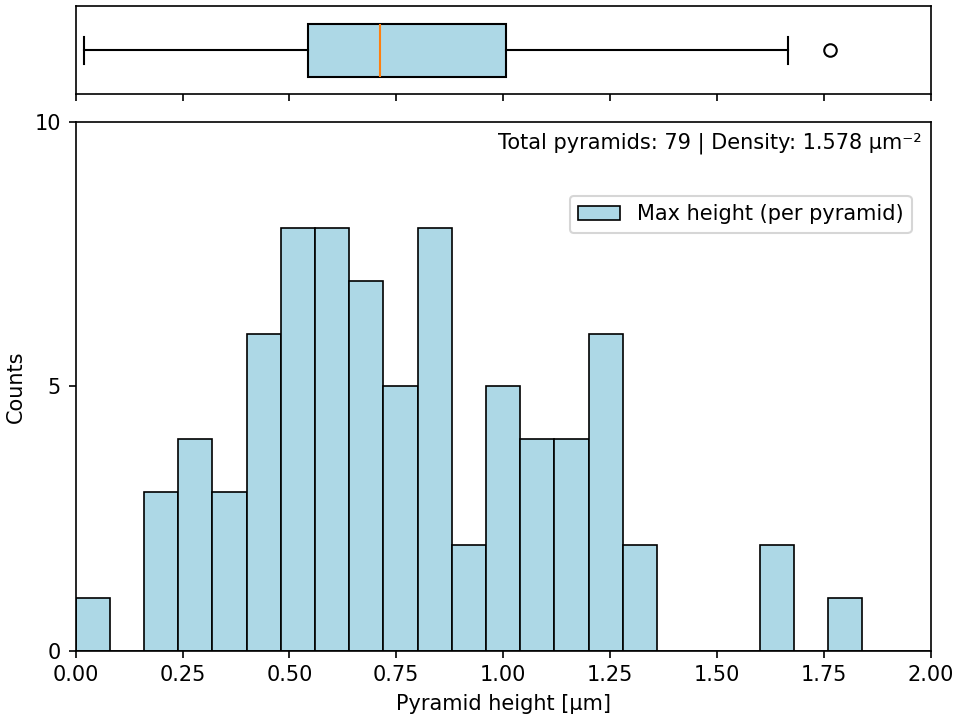

In [10]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
import imageio.v2 as imageio
import math
import os

# ─────────────────────────────────────────────────────────
# Settings
# ─────────────────────────────────────────────────────────
image_name = 'nano Text 50mL 70deg REAR.tif'                                                               # Change SEM Image Name 
ps = 0.00331                                                                                    # Change Pixel Size 
angle = 54.6                                                                                    # Change facet angle (Theoretical Angle: 54.7)) 

R = (0.0, 2.0)   # histogram x-range
bins = 25        # number of bins

crop_h = 1785     # crop height used in your pipeline

# ─────────────────────────────────────────────────────────
# Load measurements
# ─────────────────────────────────────────────────────────
BASE_DIR = "./results/Unbordered_Maximum"
DIR_SEG  = os.path.join(BASE_DIR, "segmentation_max")
DIR_PYR  = os.path.join(BASE_DIR, "pyramid_data_max")
os.makedirs(DIR_PYR, exist_ok=True)

sname = os.path.join(
    DIR_SEG,
    image_name.replace(".tif", "") + "- U-only method pyramid measurements.npz"
)
vertices = np.load(sname)["vertices"]  # (M,4,2)


M, _ = vertices.shape[0], vertices.shape[1]

# ─────────────────────────────────────────────────────────
# Pyramid area (µm²)
# ─────────────────────────────────────────────────────────
img = imageio.imread("./images/" + image_name)
img = img[:crop_h, :]   # only if your analysis used that crop

H, W = img.shape[:2]
A_um2 = (H * W) * (ps ** 2)

# ─────────────────────────────────────────────────────────
# Heights (max vertex per pyramid)
# ─────────────────────────────────────────────────────────
moduli = np.sqrt(np.sum(vertices**2, axis=-1)) * ps          # (M,4) µm
height = np.tan(np.deg2rad(angle)) * moduli                  # (M,4) µm

max_idx = np.argmax(moduli, axis=1)                          # (M,)
height_max = height[np.arange(M), max_idx]                   # (M,)
height_max = height_max[np.isfinite(height_max)]
M_valid = len(height_max)

density_valid = M_valid / A_um2

print(f"Area = {A_um2:.2f} µm²")
print(f"Pyramid density = {density_valid:.4f} µm⁻²")

# ─────────────────────────────────────────────────────────
# SAVE max pyramid height data to NPZ
# ─────────────────────────────────────────────────────────
save_dir = DIR_PYR
os.makedirs(save_dir, exist_ok=True)

out_npz = os.path.join(save_dir, image_name.replace(".tif", "_heightmax.npz"))

np.savez(
    out_npz,
    image=image_name,
    height_max=height_max,     # <-- the data you want later
    ps=ps,
    angle=angle,
    M=M_valid,
    density_um2=density_valid,
    area_um2=A_um2,
    crop_h=crop_h,
    R=np.array(R),
    bins=bins
)

print(f"Saved pyramid height max NPZ: {out_npz} (N={M_valid})")

# ─────────────────────────────────────────────────────────
# Bin summary
# ─────────────────────────────────────────────────────────
counts, edges = np.histogram(height_max, bins=bins, range=R)
print(f"\nBlue bars sum = {counts.sum()} (expected {M_valid})")

nz = np.nonzero(counts)[0]
print("\nMax heights (blue) — non-empty bins:")
print(f"{'Bin':>3} {'range [µm]':>22} {'mid [µm]':>10} {'count':>8} {'% of pyramids':>14}")

for seq, i_bin in enumerate(nz, start=1):
    lo, hi = edges[i_bin], edges[i_bin+1]
    mid = 0.5 * (lo + hi)
    cnt = int(counts[i_bin])
    pct = 100.0 * cnt / M_valid if M_valid else 0.0
    print(f"{seq:>3} [{lo:.3f}, {hi:.3f}) {mid:>10.3f} {cnt:>8d} {pct:>14.1f}%")

# ─────────────────────────────────────────────────────────
# Plot: boxplot (top) + histogram (bottom)
# ─────────────────────────────────────────────────────────
fig = plt.figure(dpi=150, constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 6], hspace=0.02)

ax_box = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_box)

# ax.hist(height_max, bins=bins, range=R, color='lightblue', edgecolor='k', linewidth=0.8)
ax.hist(height_max, bins=bins, range=R, color='lightblue', edgecolor='k', linewidth=0.8,
        label='Max height (per pyramid)')
ax.set_xlabel('Pyramid height [µm]')
ax.set_ylabel('Counts')

ax_box.boxplot(height_max, vert=False, widths=0.6, showfliers=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
ax_box.set_yticks([])
ax_box.tick_params(axis='x', labelbottom=False)

ax.set_xlim(R)
ax_box.set_xlim(R)

step = 5
ax.yaxis.set_major_locator(MultipleLocator(step))
ymax = ax.get_ylim()[1]
ax.set_ylim(0, step * math.ceil(ymax / step))

summary = f"Total pyramids: {M_valid} | Density: {density_valid:.3f} µm⁻²"
ax.text(0.99, 0.98, summary, transform=ax.transAxes, ha='right', va='top')

ax.legend(loc='upper right', bbox_to_anchor=(0.99, 0.88))


### Step 11 — Summarise the maximum pyramid-height distribution

This cell loads the `_heightmax.npz` file and reports the number of valid detected pyramids, the pyramid density, and the main height statistics.

As with the vertex-size analysis, the output switches between mean ± standard deviation and median with IQR depending on the normality-test result. For thesis reporting, the median and IQR can be especially useful because they describe the typical pyramid height and the upper part of the height distribution without relying strongly on extreme maximum values.

In [11]:
# --- Normality + conditional summary (loads from pyramid_data_max) ---
import numpy as np
from scipy import stats
import os

# ─────────────────────────────────────────────────────────
# Pick which dataset to analyze
# ─────────────────────────────────────────────────────────

# Folder where you saved the max-height results
BASE_DIR = "./results/Unbordered_Maximum"
save_dir = os.path.join(BASE_DIR, "pyramid_data_max")

# Construct the saved NPZ filename
image_name = 'nano Text 50mL 70deg REAR.tif' # <-- change this (the SEM image name you processed)                    # Change SEM Image Name 
npz_path = os.path.join(save_dir, image_name.replace(".tif", "_heightmax.npz"))

# ─────────────────────────────────────────────────────────
# Load height_max from NPZ
# ─────────────────────────────────────────────────────────
d = np.load(npz_path, allow_pickle=True)
data = np.asarray(d["height_max"])
data = data[np.isfinite(data)]
N = data.size

print("Loaded:", npz_path)
print("N (valid pyramids) =", N)

# (Optional) show metadata if present
if "density_um2" in d.files:
    print(f"Density = {float(d['density_um2']):.4f} µm⁻²")
if "ps" in d.files and "angle" in d.files:
    print(f"ps = {float(d['ps'])} µm/pixel | angle = {float(d['angle'])}°")

# ─────────────────────────────────────────────────────────
# Normality test
# ─────────────────────────────────────────────────────────
if N <= 5000:
    stat, p = stats.shapiro(data)      # Shapiro–Wilk
    test_name = "Shapiro–Wilk"
else:
    stat, p = stats.normaltest(data)   # D’Agostino K²
    test_name = "D’Agostino K²"

mean   = data.mean()
sd     = data.std(ddof=1)
q25, median, q75 = np.percentile(data, [25, 50, 75])
iqr = q75 - q25

nm = 1000.0  # µm -> nm
is_normal = p >= 0.05

print(f"\n{test_name} p = {p:.4g} -> {'normal' if is_normal else 'NOT normal'}")

if is_normal:
    print(f"Mean ± SD   : {mean:.4f} ± {sd:.4f} µm || {mean*nm:.1f} ± {sd*nm:.1f} nm")
    print(f"Median [IQR]: {median:.4f} [{q25:.4f}, {q75:.4f}] µm || "
          f"{median*nm:.1f} [{q25*nm:.1f}, {q75*nm:.1f}] nm")
    print(f"Quartiles   : Q1={q25:.4f} µm, Q2/Median={median:.4f} µm, Q3={q75:.4f} µm "
          f"|| {q25*nm:.1f}, {median*nm:.1f}, {q75*nm:.1f} nm")
else:
    print(f"Median [IQR]: {median:.4f} [{q25:.4f}, {q75:.4f}] µm || "
          f"{median*nm:.1f} [{q25*nm:.1f}, {q75*nm:.1f}] nm")
    print(f"IQR (Q3−Q1) : {iqr:.4f} µm || {iqr*nm:.1f} nm")
    print(f"Quartiles   : Q1={q25:.4f} µm, Q2/Median={median:.4f} µm, Q3={q75:.4f} µm "
          f"|| {q25*nm:.1f}, {median*nm:.1f}, {q75*nm:.1f} nm")


Loaded: ./results/Unbordered_Maximum\pyramid_data_max\ST1 REAR_heightmax.npz
N (valid pyramids) = 35
Density = 0.4490 µm⁻²
ps = 0.00413 µm/pixel | angle = 54.6°

Shapiro–Wilk p = 0.1071 -> normal
Mean ± SD   : 1.2777 ± 0.5497 µm || 1277.7 ± 549.7 nm
Median [IQR]: 1.1753 [0.8835, 1.7218] µm || 1175.3 [883.5, 1721.8] nm
Quartiles   : Q1=0.8835 µm, Q2/Median=1.1753 µm, Q3=1.7218 µm || 883.5, 1175.3, 1721.8 nm


### Step 12 — Export maximum vertex size, orientation, and height to Excel

This final export cell converts the `.npz` measurement data into an Excel table. For each detected pyramid, it saves:

- the maximum vertex size,
- the orientation of the maximum ray,
- the estimated maximum pyramid height.

This is useful for making appendix tables, checking individual-pyramid values, or combining the SEM output with other experimental data outside Python.

In [12]:
import os
import numpy as np
import pandas as pd
import openpyxl  # noqa: F401 (kept because you said you're using it)

ps = 0.00331  # µm / pixel                                                                            # Change Pixel Size 
angle = 54.6                                                                                          # Change facet angle (Theoretical Angle: 54.7)) 

image_names = [
    #"SOX1.tif",
    'nano Text 50mL 70deg REAR.tif',                                                                               # Change SEM Image Name 
]

# ─────────────────────────────────────────────────────────
# Folder structure (Unbordered_Maximum)
# ─────────────────────────────────────────────────────────
BASE_DIR = "./results/Unbordered_Maximum"
DIR_SEG  = os.path.join(BASE_DIR, "segmentation_max")
DIR_XLSX = os.path.join(BASE_DIR, "excel_max")

os.makedirs(DIR_XLSX, exist_ok=True)

for image_name in image_names:
    # Load measurements from segmentation_max
    sname = os.path.join(
        DIR_SEG,
        image_name.replace(".tif", "") + "- U-only method pyramid measurements.npz"
    )
    data = np.load(sname)
    vertices = data["vertices"]  # (M,4,2)

    # Max vertex per pyramid
    moduli = np.sqrt(np.sum(vertices**2, axis=-1)) * ps  # (M,4) in µm
    angles = np.arctan2(vertices[..., 1], vertices[..., 0])  # (M,4) radians

    max_indices = np.argmax(moduli, axis=1)  # (M,)
    moduli_max  = moduli[np.arange(moduli.shape[0]), max_indices]
    angles_max  = angles[np.arange(angles.shape[0]), max_indices]

    # Orientation in degrees (0..360)
    angles_max_deg = np.rad2deg(angles_max + np.pi)

    # Height from max vertex
    height_max = np.tan(np.deg2rad(angle)) * moduli_max

    # Save Excel into excel_max (same naming style)
    out_xlsx = os.path.join(
        DIR_XLSX,
        image_name.replace(".tif", "") + "- U-only method pyramid measurements.xlsx"
    )

    df = pd.DataFrame({
        "Modulus [um]": moduli_max,
        "Orientation [deg]": angles_max_deg,
        "Height [um]": height_max
    })

    df.to_excel(out_xlsx, index=False, sheet_name="data")
    print("Saved:", out_xlsx)


Saved: ./results/Unbordered_Maximum\excel_max\NT3-C REAR E- U-only method pyramid measurements.xlsx
